<a href="https://colab.research.google.com/github/Teapot-t/kurs-Uczenie-Maszynowe/blob/main/Zadanie_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gensim

In [ ]:
#importy, ładowanie embeddingu
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import gensim.downloader as api

model = api.load("glove-wiki-gigaword-100")

###Wybór słów
Zacząłem od wyboru klas do wykonania zadania wraz z utworzeniem powiązanych ze sobą par słów. Celowo kilka (ale niewiele) słów nalezy do różnych klas (np nazwy krajów) żeby zobaczyć jak wyglądają powiązania między klasami. Do analizy wykorzystamy embedding GloVe 100d

In [ ]:
# 1. gender
gender = [
('king', 'queen'),
('man', 'woman'),
('doctor', 'nurse'),
('prince', 'princess'),
('boy','girl')
]

# 2. Social status relation
social_status = [
('employer','employee'),
('boss', 'worker'),
('teacher', 'student'),
('manager', 'intern'),
('chef', 'waiter')
]

# 3. tool/user
tool_user = [
('painter','brush'),
('driver','car'),
('photographer','camera'),
('writer','pen'),
('carpenter', 'wood')
]

# 4. city/country
city_country = [
('warsaw','poland'),
('london','england'),
('berlin','germany'),
('rome','italy'),
('tokyo','japan')
]

# 5. Currency/Country
currency_country = [
('zloty', 'poland'),
('yen', 'japan'),
('euro', 'france'),
('dollar', 'usa'),
('pound', 'britain')
]

# 6. Hyponymy/hypernymy
hyponymy_hypernymy = [
('colour', 'red'),
('science', 'physics'),
('clothes', 'shirt'),
('animal', 'rabbit'),
('sport', 'football')
]

# 7. Verb tense (past tense)
verb_tense = [
('bring', 'brought'),
('get', 'got'),
('like', 'liked'),
('speak', 'spoke'),
('go', 'went')
]

# 8. Adjective intensity
adjective_intensity = [
('bright', 'brightest'),
('smart', 'smartest'),
('fast', 'fastest'),
('dark', 'darkest'),
('bad', 'worst')
]

# 9. singular/plural
singular_plural = [
('cup', 'cups'),
('glass', 'glasses'),
('man', 'men'),
('bird', 'birds'),
('meter', 'meters')
]

# 10. Adjective/adverb
adjective_adverb = [
('quick', 'quickly'),
('slow', 'slowly'),
('happy', 'happily'),
('careful', 'carefully'),
('easy', 'easily')
]

In [ ]:
classes = {
    'gender': gender,
    'social_status': social_status,
    'tool_user': tool_user,
    'city_country': city_country,
    'currency_country': currency_country,
    'hyponymy_hypernymy': hyponymy_hypernymy,
    'verb_tense': verb_tense,
    'adjective_intensity': adjective_intensity,
    'singular_plural': singular_plural,
    'adjective_adverb': adjective_adverb
}

##Globalne PCA


In [ ]:
all_words = []
for class_name, word_pairs in classes.items():
    for w1, w2 in word_pairs:
        all_words.append(w1)
        all_words.append(w2)

all_words = list(set(all_words))
word_vectors = np.array([model[word] for word in all_words])


Some words might not be present in the `glove-wiki-gigaword-100` model. These words will be excluded from the analysis.

In [ ]:
# Wykonujemy PCA
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(word_vectors)
word_to_reduced_vector = {word: vec for word, vec in zip(all_words, reduced_vectors)}


## Globalne PCA - wykresy

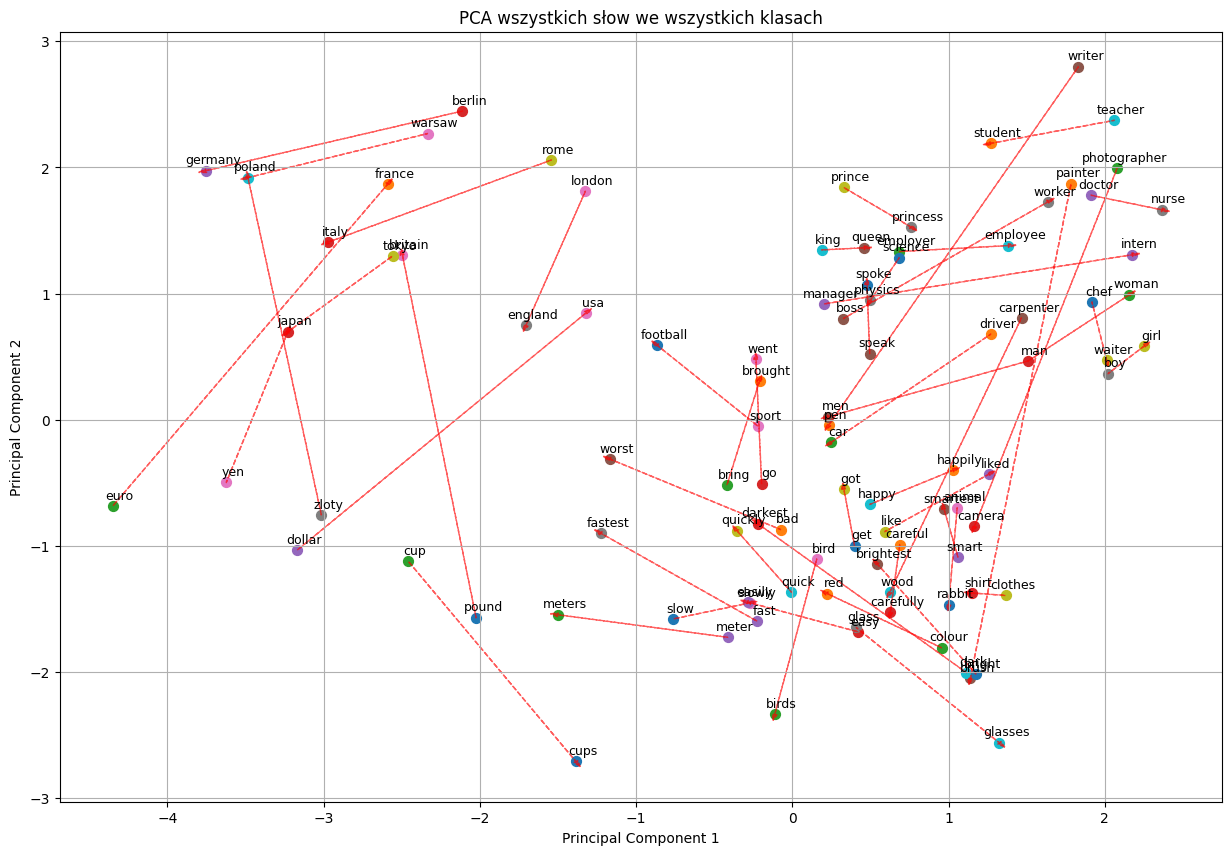

In [ ]:
plt.figure(figsize=(15, 10))

for i, word in enumerate(all_words):
    x, y = reduced_vectors[i, 0], reduced_vectors[i, 1]
    plt.scatter(x, y, s=50)
    plt.annotate(word, (x, y), textcoords="offset points", xytext=(5, 5), ha='center', fontsize=9)

# Add arrows for word pairs in all classes
for class_name, word_pairs in classes.items():
    for w1, w2 in word_pairs:
        if w1 in word_to_reduced_vector and w2 in word_to_reduced_vector:
            vec1 = word_to_reduced_vector[w1]
            vec2 = word_to_reduced_vector[w2]
            plt.arrow(vec1[0], vec1[1], vec2[0] - vec1[0], vec2[1] - vec1[1],
                      head_width=0.03, head_length=0.05, fc='red', ec='red', alpha=0.6, linestyle='--')

plt.title('PCA wszystkich słow we wszystkich klasach')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## Globalne PCA - wykresy dla pojedynczych klas

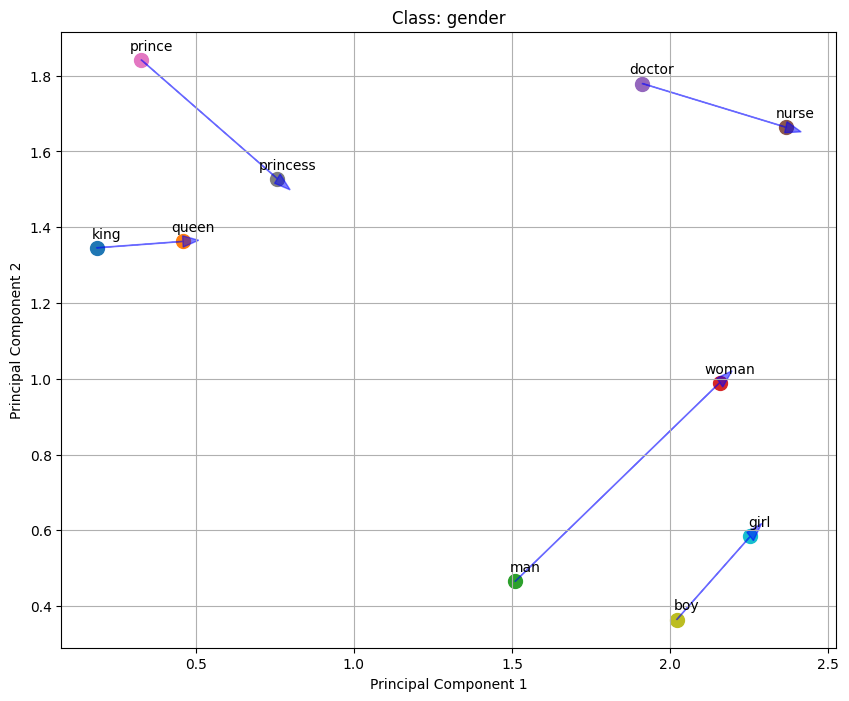

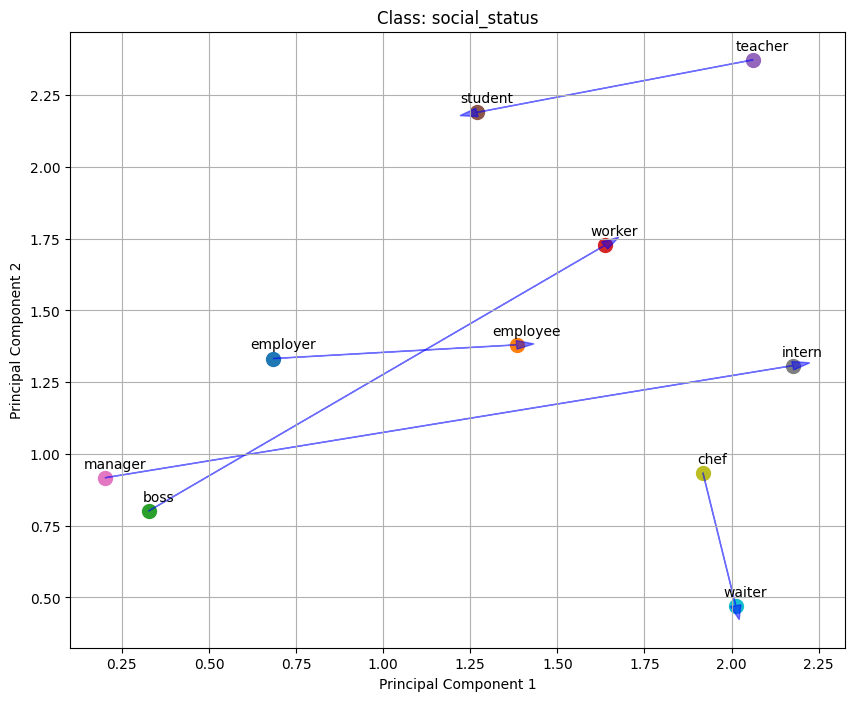

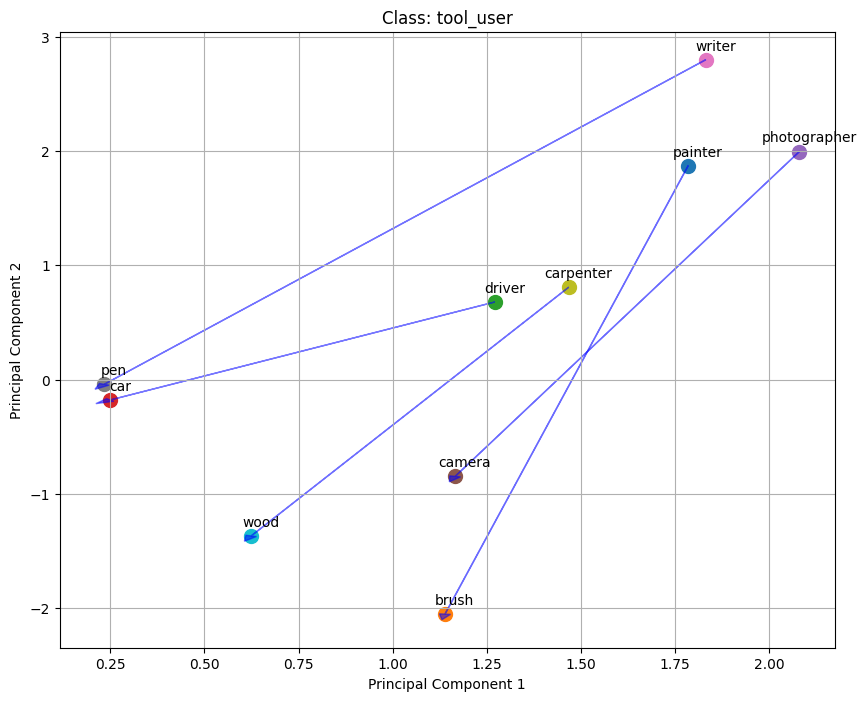

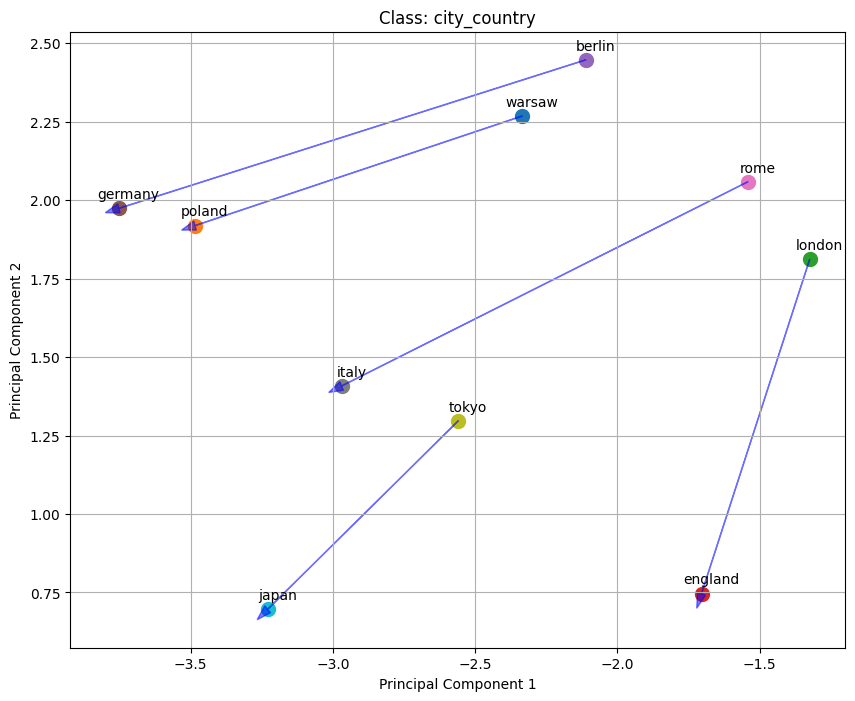

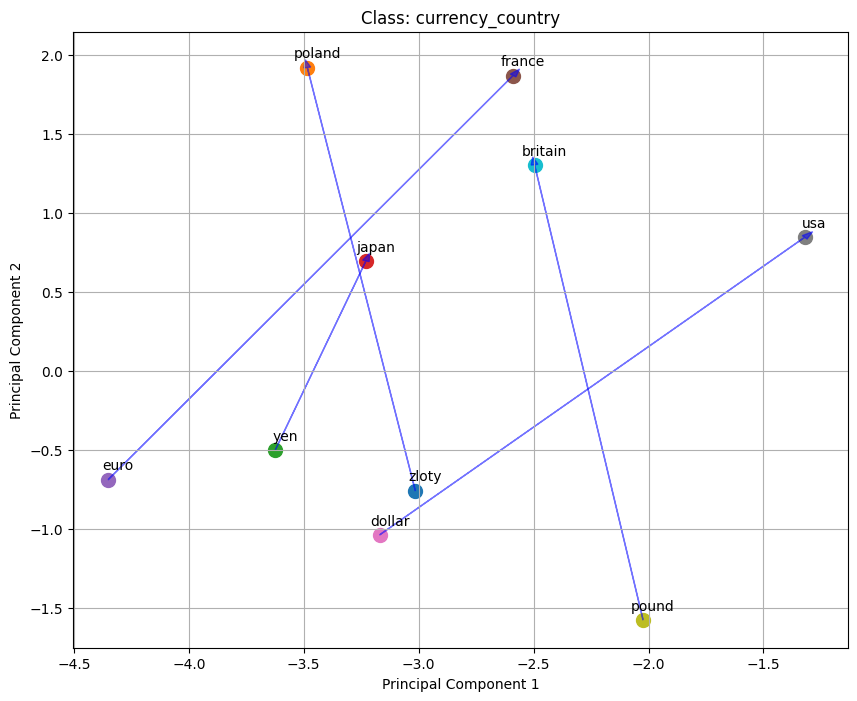

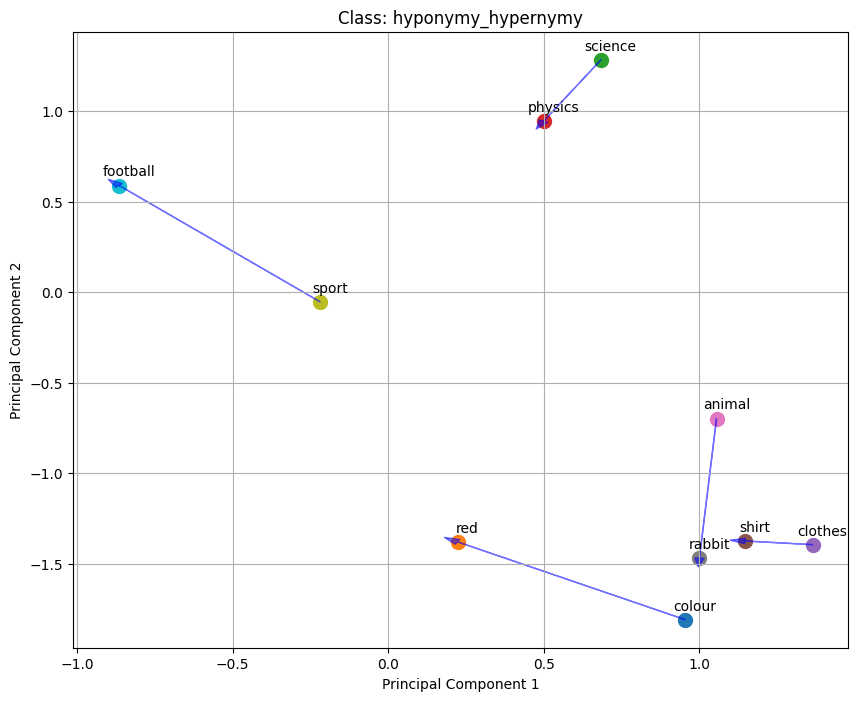

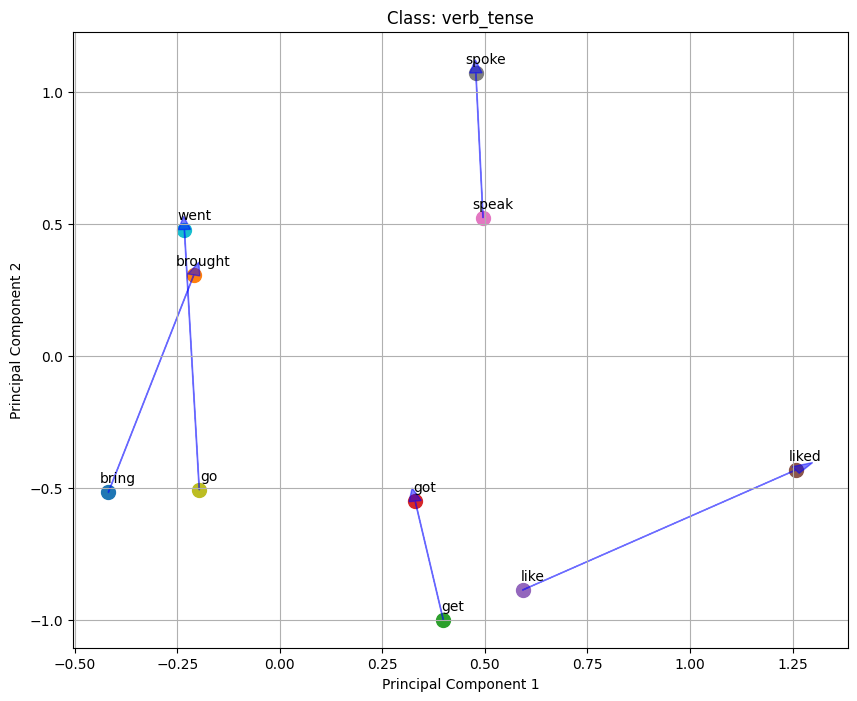

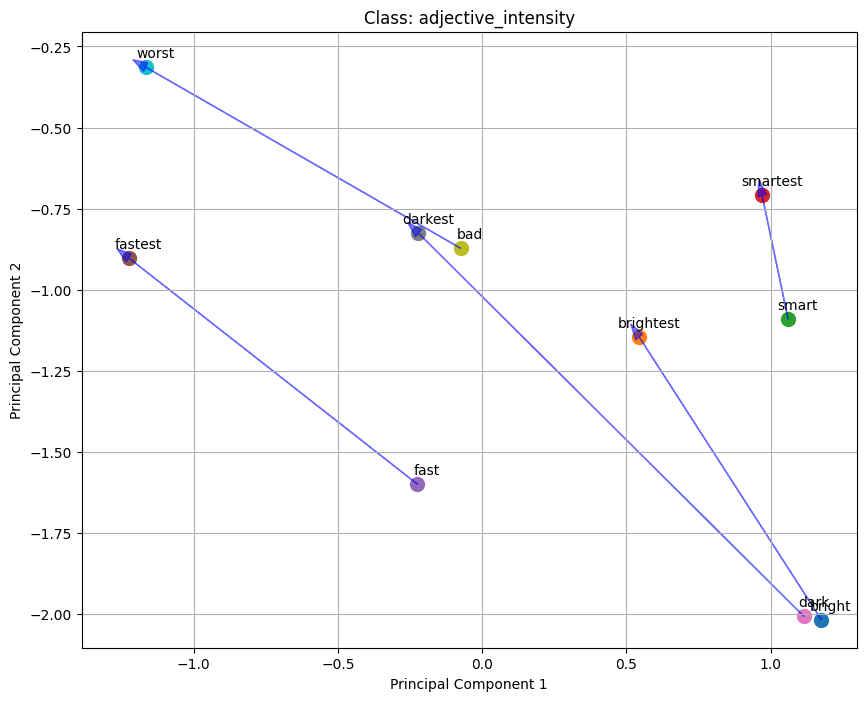

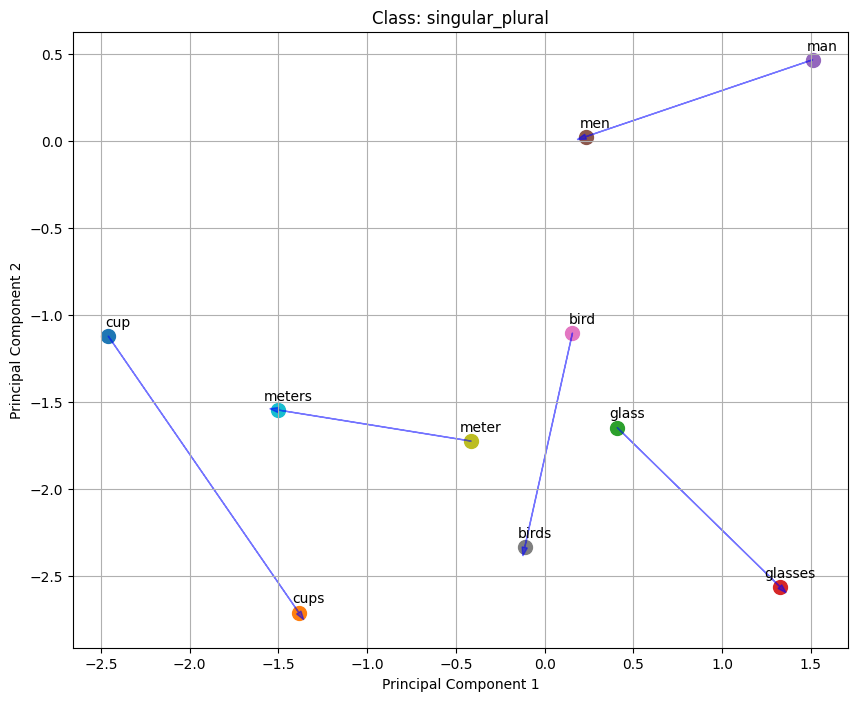

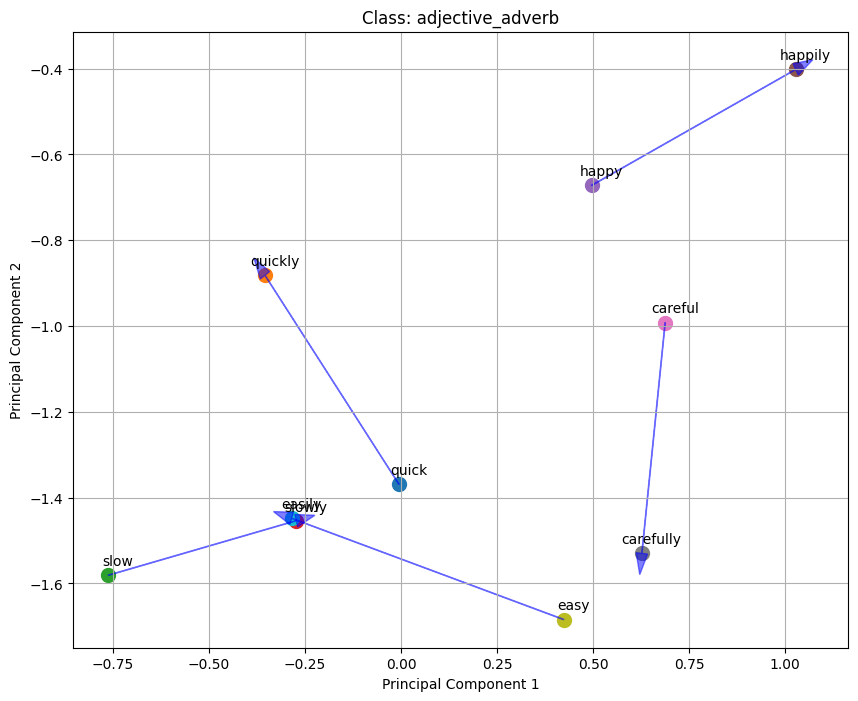

In [ ]:
for class_name, word_pairs in classes.items():
    plt.figure(figsize=(10, 8))
    plt.title(f'Class: {class_name}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)

    class_words_in_model = []
    class_vectors = []

    for w1, w2 in word_pairs:
        if w1 in word_to_reduced_vector and w2 in word_to_reduced_vector:
            class_words_in_model.append(w1)
            class_vectors.append(word_to_reduced_vector[w1])
            class_words_in_model.append(w2)
            class_vectors.append(word_to_reduced_vector[w2])

    class_reduced_vectors = np.array(class_vectors)

    #punkty i labelki
    for i, word in enumerate(class_words_in_model):
        x, y = class_reduced_vectors[i, 0], class_reduced_vectors[i, 1]
        plt.scatter(x, y, s=100)
        plt.annotate(word, (x, y), textcoords="offset points", xytext=(7, 7), ha='center', fontsize=10)

    #strzałki
    for w1, w2 in word_pairs:
        if w1 in word_to_reduced_vector and w2 in word_to_reduced_vector:
            vec1 = word_to_reduced_vector[w1]
            vec2 = word_to_reduced_vector[w2]
            plt.arrow(vec1[0], vec1[1], vec2[0] - vec1[0], vec2[1] - vec1[1],
                      head_width=0.03, head_length=0.05, fc='blue', ec='blue', alpha=0.5)

    plt.show()


### Przechodzimy do PCA na pojedynczych klasach

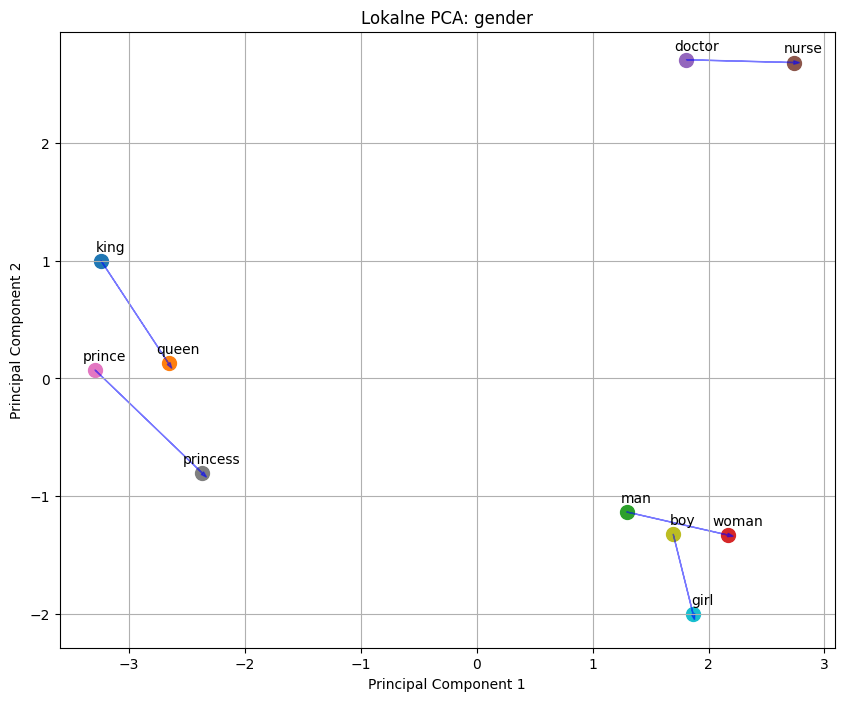

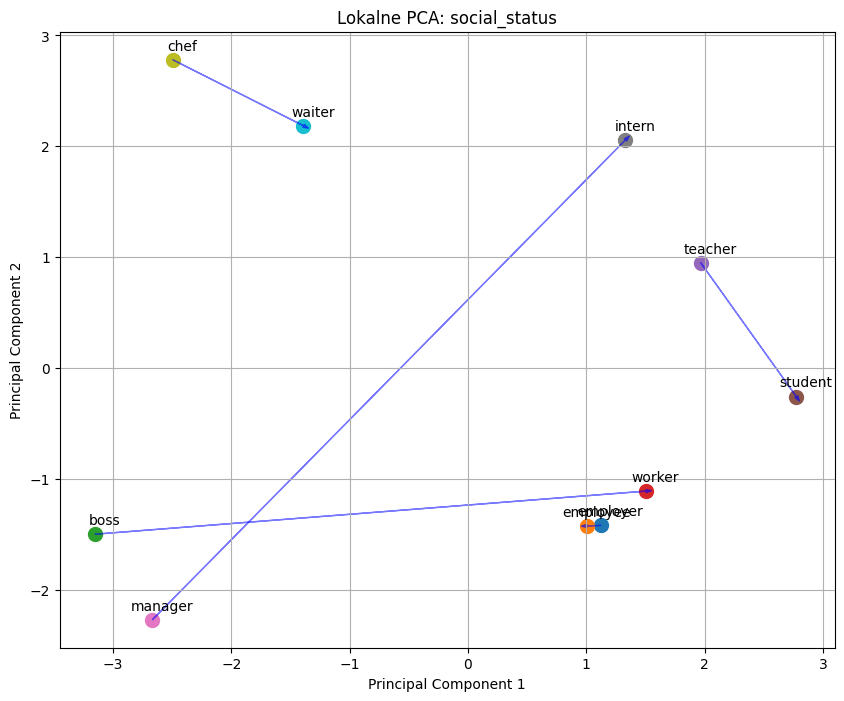

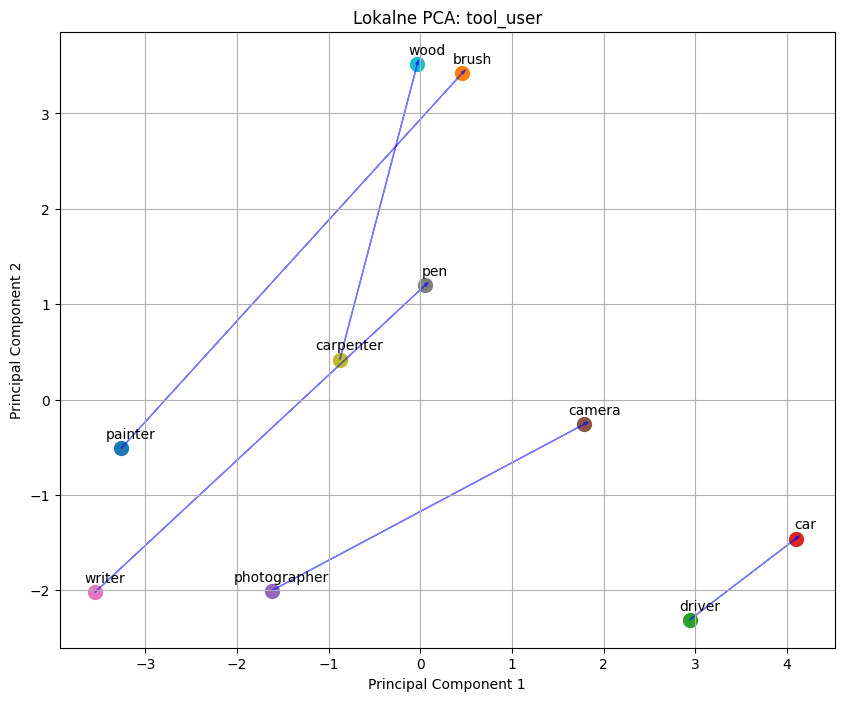

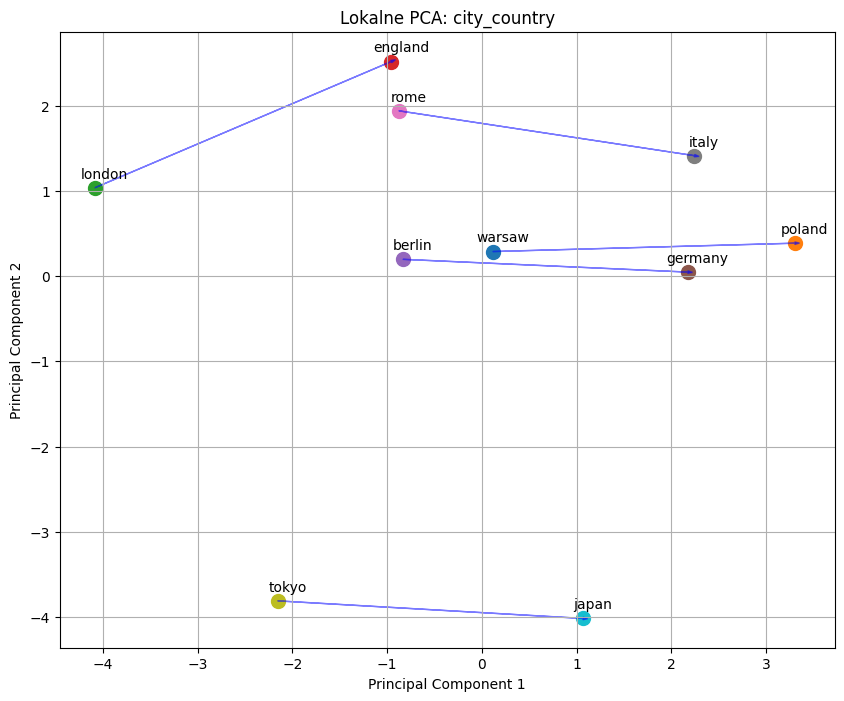

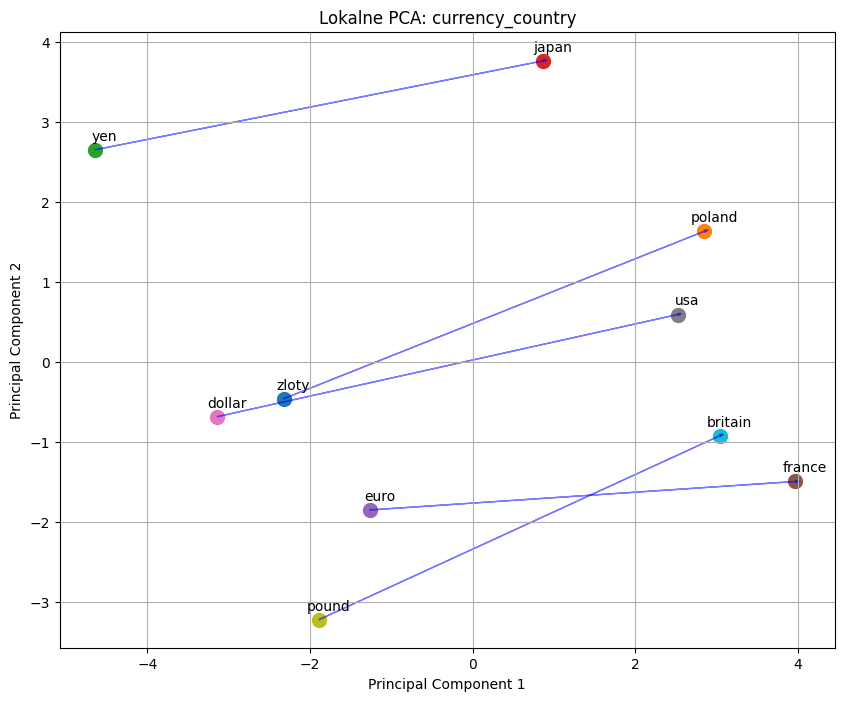

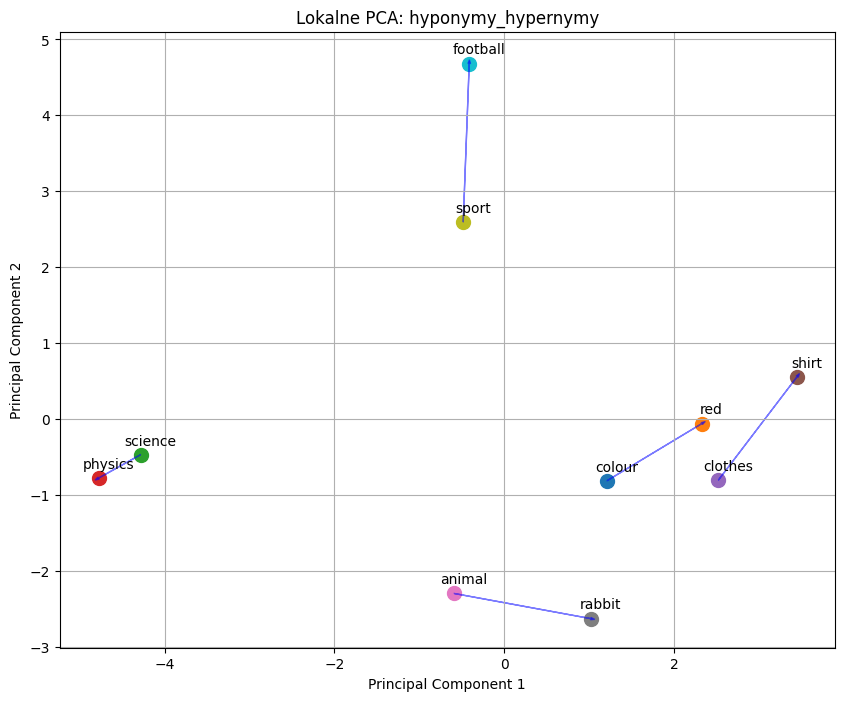

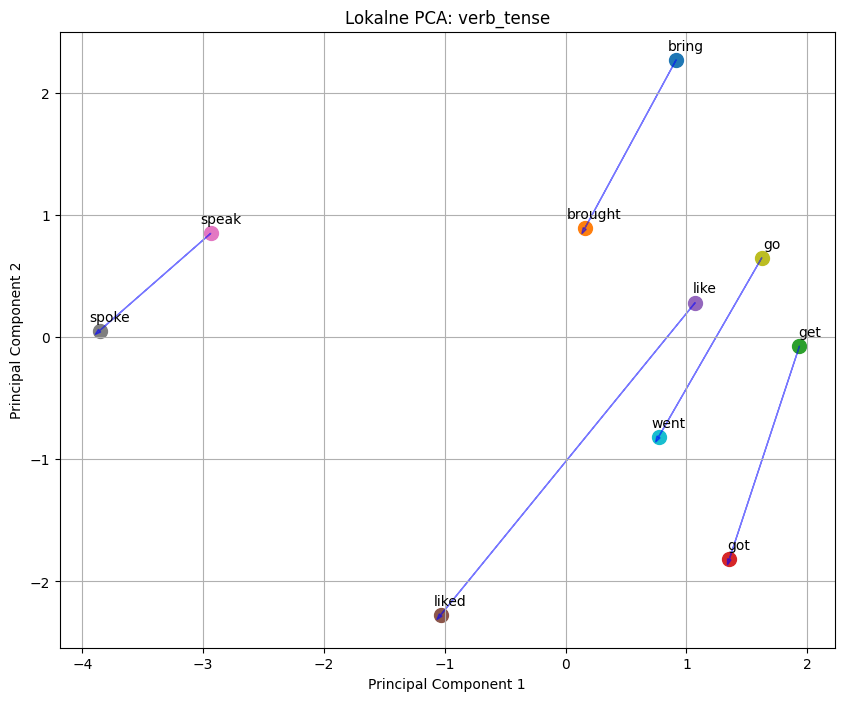

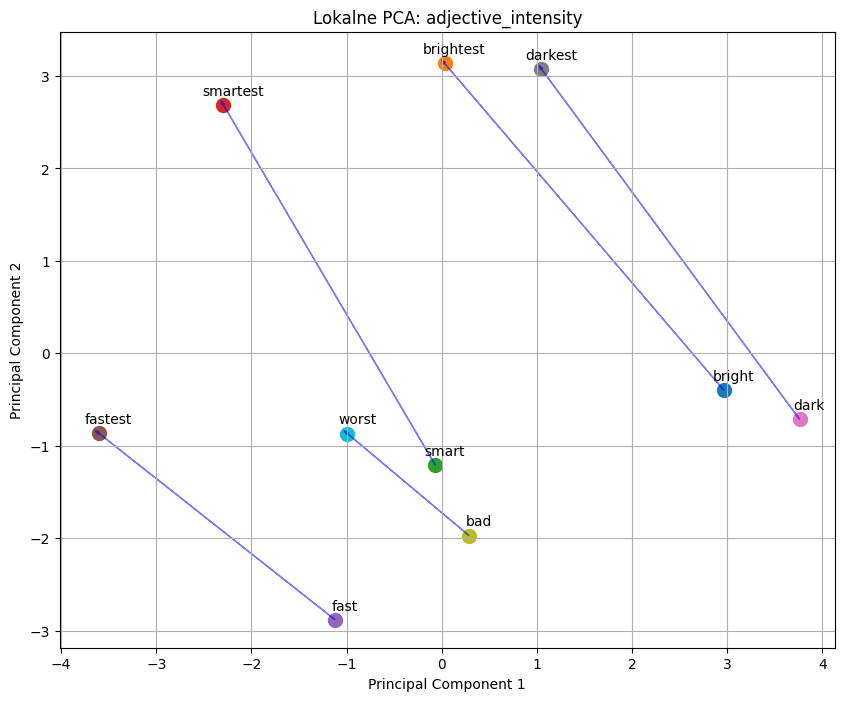

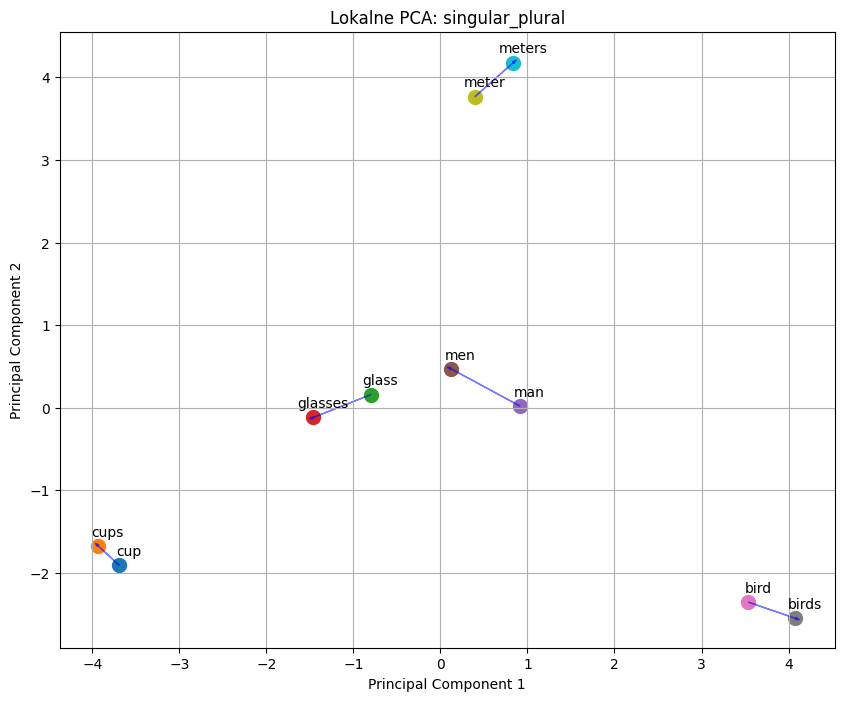

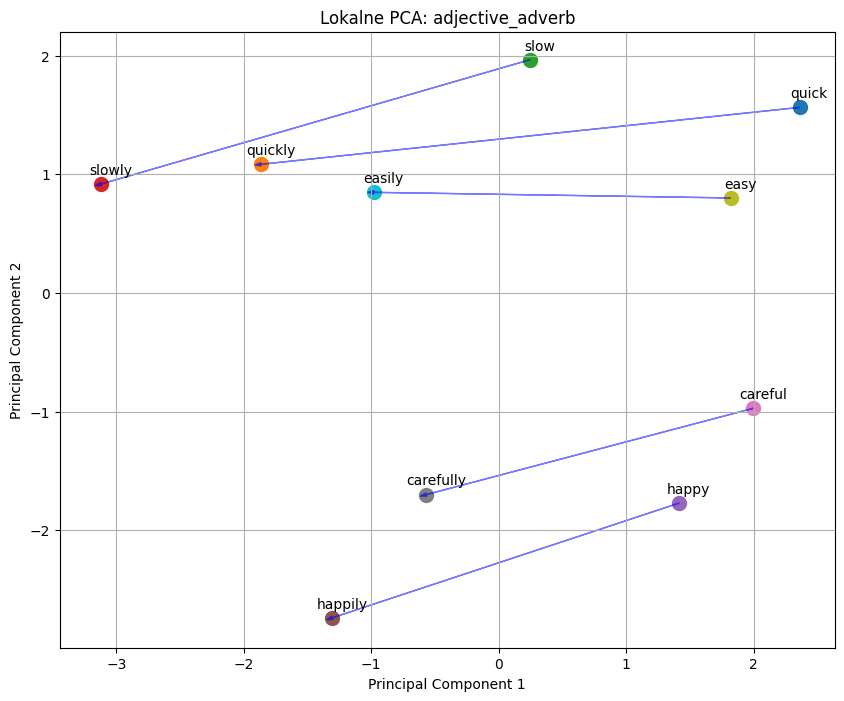

In [ ]:
for class_name, word_pairs in classes.items():
    plt.figure(figsize=(10, 8))
    plt.title(f'Lokalne PCA: {class_name}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)

    class_words_for_pca = []
    class_original_vectors = []

    for w1, w2 in word_pairs:
        if w1 in model.key_to_index and w2 in model.key_to_index:
            class_words_for_pca.append(w1)
            class_original_vectors.append(model[w1])
            class_words_for_pca.append(w2)
            class_original_vectors.append(model[w2])

    local_pca = PCA(n_components=2)
    local_reduced_vectors = local_pca.fit_transform(np.array(class_original_vectors))

    local_word_to_reduced_vector = {word: vec for word, vec in zip(class_words_for_pca, local_reduced_vectors)}

    for i, word in enumerate(class_words_for_pca):
        x, y = local_reduced_vectors[i, 0], local_reduced_vectors[i, 1]
        plt.scatter(x, y, s=100)
        plt.annotate(word, (x, y), textcoords="offset points", xytext=(7, 7), ha='center', fontsize=10)

    for w1, w2 in word_pairs:
        if w1 in local_word_to_reduced_vector and w2 in local_word_to_reduced_vector:
            vec1 = local_word_to_reduced_vector[w1]
            vec2 = local_word_to_reduced_vector[w2]
            plt.arrow(vec1[0], vec1[1], vec2[0] - vec1[0], vec2[1] - vec1[1],
                      head_width=0.03, head_length=0.05, fc='blue', ec='blue', alpha=0.5)

    plt.show()

### Teraz przeprowadzimy analizę działania arytmetyki na słowach w róznych klasach
wykonujemy operację arytmetyczną na embeddingach i sprawdzamy top5 najbliższych słów w bibliotece modelu GloVe korzystając z wbudowanej funkcji.
Powtarzamy dla każdej z 10 klas

In [ ]:
#1. gender
result = model['king'] - model['man'] + model['woman']
similar = model.similar_by_vector(result, topn=5)

for word, score in similar:
    print(word, score)

king 0.8551837205886841
queen 0.783441424369812
monarch 0.6933802366256714
throne 0.6833109855651855
daughter 0.6809081435203552


no coż, hipoteza z tytułu zadania domowego nie działa. Można tutaj coś powiedzieć o Jadwidze Andegaweńskiej koronowanej na króla Polski więc może kontekst znaczeniowy króla jako władcy dalej jest silniejszy niż sama płeć. Oczekiwana królowa jest bliskim wynikiem

In [ ]:
#2. past tense
result = model['bring'] - model['speak'] + model['spoke']
similar = model.similar_by_vector(result, topn=5)

for word, score in similar:
    print(word, score)

bring 0.7497082948684692
brought 0.7435662150382996
bringing 0.7269055247306824
adding 0.6981101036071777
meanwhile 0.6783429384231567


In [ ]:
#3. Social status relation
result = model['manager'] - model['teacher'] + model['student']
similar = model.similar_by_vector(result, topn=5)

for word, score in similar:
    print(word, score)

manager 0.8579956889152527
owner 0.6478549838066101
team 0.6424940824508667
club 0.6296736001968384
management 0.618182897567749


In [ ]:
# 4. Adjective intensity
result = model['bright'] - model['dark'] + model['darkest']
similar = model.similar_by_vector(result, topn=5)

for word, score in similar:
    print(word, score)

darkest 0.7585560083389282
bleakest 0.615759015083313
brightest 0.5999749898910522
clearest 0.569493293762207
saddest 0.5642032027244568


In [ ]:
# 5. city/country
city_country = [
('warsaw','poland'),
('london','england'),
('berlin','germany'),
('rome','italy'),
('tokyo','japan')
]
result = model['warsaw'] - model['poland'] + model['england']
similar = model.similar_by_vector(result, topn=5)

for word, score in similar:
    print(word, score)

birmingham 0.7476530075073242
england 0.7375290393829346
london 0.7287718653678894
melbourne 0.70290207862854
leeds 0.6975002884864807


birmingham nie było wynikiem którego się spodziewałem. z Warszawy i Polski został tylko niższy status społeczny dodany do Londynu...

In [ ]:
# 6. singular/plural
result = model['glass'] - model['bird'] + model['birds']
similar = model.similar_by_vector(result, topn=5)

for word, score in similar:
    print(word, score)
print("druga runda")
result = model['man'] - model['bird'] + model['birds']
similar = model.similar_by_vector(result, topn=5)

for word, score in similar:
    print(word, score)

glass 0.8031082153320312
plastic 0.6757216453552246
pieces 0.6533840298652649
walls 0.6437018513679504
ceramic 0.6187669634819031
druga runda
man 0.7575109004974365
young 0.6722378134727478
men 0.6628357172012329
they 0.6576161980628967
sometimes 0.6489811539649963


In [ ]:
# 7. tool/user
result = model['painter'] - model['driver'] + model['car']
similar = model.similar_by_vector(result, topn=5)

for word, score in similar:
    print(word, score)

painter 0.8364452719688416
painting 0.782053530216217
paintings 0.7521389722824097
sculptor 0.7347238659858704
sculpture 0.7184174656867981


In [ ]:
# 8. Currency/Country
result = model['zloty'] - model['yen'] + model['japan']
similar = model.similar_by_vector(result, topn=5)

for word, score in similar:
    print(word, score)

turkey 0.6026919484138489
poland 0.5772063732147217
kazakhstan 0.5640769600868225
latvia 0.5499699115753174
romania 0.5474384427070618


In [ ]:
# 9. Hyponymy/hypernymy
result  = model['colour'] - model['animal'] + model['dog']
similar = model.similar_by_vector(result, topn=5)

for word, score in similar:
    print(word, score)

colour 0.7633858323097229
color 0.6715947985649109
yellow 0.5994645357131958
pink 0.594219982624054
colors 0.59072345495224


In [96]:
# 10. Adjective/adverb
result = model['quick'] - model['slow'] + model['slowly']
similar = model.similar_by_vector(result, topn=5)

for word, score in similar:
    print(word, score)

quickly 0.7115532755851746
slowly 0.6819995641708374
quick 0.651126503944397
then 0.6106505393981934
finally 0.5981444716453552


### Analiza globalnego PCA
Przede wszystkim, wykorzystywany embedding korzysta z 100 wymiarów do zanurzania naszej przestrzeni słownika. Rzut na przestrzeń 2d poddaje dane bardzo silnej kompresji - będąc blisko na wykresie punkty mogą być daleko siebie w całej przestrzeni 100 wymiarowej.

Na centralnym wykresie globalnego PCA widać klastrowanie się podobnych znaczeniowo słów. na pierwszy rzut oka można zauważyć klaster dotyczący ludzi, klaster "geopolityczny" z państwami, miastami, walutami, i klaster "zwykłych/popularnych" słow - przymiotników i przedmiotów. Pokusiłbym się nawet o hipotezę, że, na bazie wybranych słów, kierunek w prawo i do góry odpowiada jakiegoś rodzaju uczłowieczeniu - dwa procesy:
słowa dotyczące ludzi i zawodów -> czasowniki i przymiotniki opisujące osoby -> przedmioty
oraz:
waluta (abstrakcyjna i bezosobowa) <- państwa (twór geopolityczny) <- miasta (w których mieszkają ludzie)
być może to tylko nadmierna chęć znalezienia wzorca w działaniu embeddingu
ciężko natomiast na tym wykresie zobaczyć jak działają nasze klasy semantyczne jako że są dość mocno wymieszane ze sobą.

### Analiza globalnego PCA - pojedyncze klasy
Już nawet dla globalnego PCA dla większości klas widać ogólny trend kierunków, w których są przesówane punkty w ramach naszego embeddingu. Klasy "znaczeniowe" mają generalnie lepszy performance niż klasy "gramatyczne" jeśli chodzi o ustalanie kierunku - bliskie sklastrowanie par punktów z liczby pojedynczej/mnogiej wprowadza chaos w kierunkach w globalnym PCA i utrudnia wyznaczenie jednego kierunku w którym przesówamy punkty. Tak samo bardziej abstrakcyjne koncepty jak klasa ogólności pojęcia albo kierunek relacji/statusu społecznego są słabo wychwytywane w 2 wymiarowym PCA

### Pojedyncze klasy
Łatwo się spodziewać, że wykonanie PCA na pojedynczych klasach da lepszą wizualizację kierunków klas. Jedyne klasy dla których model nie był w stanie wyznaczyć kierunku trendu to hyponymy_hypernymy oraz liczba pojedyncz i mnoga. W pierwszym przypadku, najprawdopodobniej wszystkie obiekty z danej kategorii klastrują się wokół tej ogólnej, niekoniecznie wyznaczając jeden kierunek. Podsobnie z liczbą pojedynczą i mnogą. Widać też, że punkty będące w parze są relatywnie blisko siebie natomiast pary relatywnie daleko - to nie te relacje są czynnikiem rużnicującym klasę w ramach wybranego przez nas embeddingu.

### Arytmetyka na słowach
Niestety, mimo że byłoby to bardzo ciekawą konsekwencją, arytmetyka wykonywana na słowach z danej klasy nie daje oczekiwanych efektów. Model nie ma pojedynczego wektora opisującego zmianę względem jednej klasy, słowa są umieszczone w dużo bardziej skomplikowanych relacjach. Najczęściej wynikiem są słowa podobne do jednego z bezpośrednio użytych słow. W niektórych przypadkach, nawet z odpowiedniej części klasy, jak np. tylko nazwy miast lub państw. Niemniej, oczekiwany wynik częściej niż nie (7/10 przypadków) pojawiał się w top5 najbliższych wyników.
Aby otrzymać tego rodzaju arytmetykę dostatecznie dobrze trzebaby wstrzelić się w kierunki opisane przez 100 zmiennych wykorzystywanych przez nasz embedding albo ich bezpośrednie kombinacje liniowe. W każym innym przypadku zaburzenie tej relacji będzie oznaczało inne kąty nachylenia strzałek, co zaburzy dokładność takiej arytmetyki.